## **Week 18 · Day 5 — Actor–Critic (A2C)**

### **Why this matters**

The **Actor–Critic** method combines the best of both worlds:

* **Policy gradients** (actor) learn *which actions to take*,
* **Value functions** (critic) learn *how good each state is*.
  This reduces variance and speeds up training — forming the basis of modern RL algorithms (A3C, PPO, etc.).

---

### **Theory Essentials**

* **Actor:** outputs a policy πθ​(a∣s).
* **Critic:** estimates a value function Vw(s)≈E[Gt∣st=s].
* **Advantage:** ( A_t = G_t - V(s_t) ) measures if action *a* was better than expected.
* **Actor loss:** ( L_{actor} = -\log \pi(a_t|s_t) A_t ).
* **Critic loss:** ( L_{critic} = (G_t - V(s_t))^2 ).
* **Total loss:** ( L = L_{actor} + c \cdot L_{critic} ).
* **Goal:** lower variance, faster convergence than REINFORCE.

---




### 🧩 Where A2C fits

You’ve already seen:

| Method            | Learns                       | Type                  | Problem                              |
| ----------------- | ---------------------------- | --------------------- | ------------------------------------ |
| **Q-Table / DQN** | Value of each action         | *Value-based*         | Unstable for large/continuous spaces |
| **REINFORCE**     | Policy directly (what to do) | *Policy-based*        | High variance, slow convergence      |
| **A2C**           | Both policy **and** value    | *Actor–Critic hybrid* | Combines their strengths             |

---

### 🧠 Why we use it

* REINFORCE learns directly from total returns → **very noisy** updates.
* A2C adds a **Critic** that estimates *how good the current state is* → gives a **baseline** that reduces variance.
* The **Actor** still learns *how to act*, but now guided by the Critic’s feedback.

---

### ⚙️ How it works conceptually

1. **Actor (πθ)** chooses an action → defines *probabilities* of each move.
2. **Critic (Vw)** estimates the *value of the current state*.
3. When the reward comes, we compute an **Advantage**:
   [
   A_t = G_t - V(s_t)
   ]
   → “Was that action better than expected?”
4. Update:

   * **Actor**: increase probability of actions with positive advantage
   * **Critic**: adjust to make V(s) closer to observed return Gt

---

### 🎮 Analogy

Imagine a game coach (Critic) and a player (Actor):

* The **player** decides moves (policy).
* The **coach** evaluates how good those moves were compared to expectations.
  The feedback loop helps the player improve **faster and more consistently** than learning alone.

---

### 🚀 In short

> **A2C = REINFORCE + a learned baseline (Critic).**
> It’s more stable, learns faster, and is the foundation for modern RL methods like **A3C**, **PPO**, and **DDPG**.

---



Episode   50 | Mean reward (last 50): 18.4
Episode  100 | Mean reward (last 50): 20.5
Episode  150 | Mean reward (last 50): 26.9
Episode  200 | Mean reward (last 50): 37.8
Episode  250 | Mean reward (last 50): 42.3
Episode  300 | Mean reward (last 50): 60.6
Episode  350 | Mean reward (last 50): 87.2
Episode  400 | Mean reward (last 50): 118.9
Episode  450 | Mean reward (last 50): 163.5
Episode  500 | Mean reward (last 50): 199.8


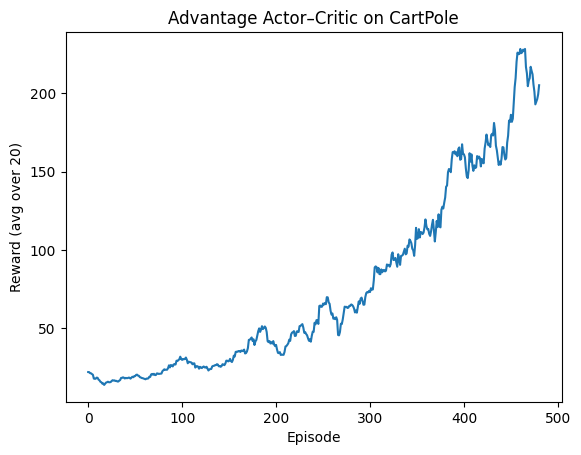

Final mean reward (last 50): 199.82


In [1]:
# Setup
import numpy as np, matplotlib.pyplot as plt
import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
np.random.seed(42); torch.manual_seed(42)

# Environment
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Actor–Critic network
class ActorCritic(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU()
        )
        self.policy = nn.Sequential(
            nn.Linear(hidden, n_actions), nn.Softmax(dim=-1)
        )
        self.value = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.shared(x)
        return self.policy(x), self.value(x)

model = ActorCritic()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
gamma = 0.99
episodes = 500
critic_coef = 0.5

def compute_returns(rewards, gamma=0.99):
    G, ret = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        ret.append(G)
    ret.reverse()
    ret = torch.tensor(ret, dtype=torch.float32)
    if ret.std() > 0:
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    return ret

reward_hist = []

for ep in range(episodes):
    logprobs, values, rewards = [], [], []
    s, info = env.reset()
    terminated = truncated = False
    ep_reward = 0.0

    while not (terminated or truncated):
        s_t = torch.tensor(s, dtype=torch.float32)
        probs, value = model(s_t)
        m = Categorical(probs)
        a = m.sample()
        s_next, r, terminated, truncated, info = env.step(a.item())

        logprobs.append(m.log_prob(a))
        values.append(value)
        rewards.append(r)
        ep_reward += r
        s = s_next

    # Compute returns and advantages
    returns = compute_returns(rewards, gamma)
    values = torch.cat(values).squeeze()
    advantage = returns - values.detach()

    # Losses
    actor_loss = -(torch.stack(logprobs) * advantage).mean()
    critic_loss = (returns - values).pow(2).mean()
    loss = actor_loss + critic_coef * critic_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_hist.append(ep_reward)

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1:4d} | Mean reward (last 50): {np.mean(reward_hist[-50:]):.1f}")

# Plot learning curve
window = 20
ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
plt.plot(ma)
plt.title("Advantage Actor–Critic on CartPole")
plt.xlabel("Episode")
plt.ylabel(f"Reward (avg over {window})")
plt.show()

print("Final mean reward (last 50):", np.mean(reward_hist[-50:]))


1) Core (10–15 min)

Task: Compare learning curves with REINFORCE (Day 4). Which is smoother?


They look simialr but the one using reinforce is slightly smoother.

2) Practice (10–15 min)

Task: Tune critic_coef (0.2, 0.5, 1.0) — see how it changes training stability.
Hint: Higher = stronger value function learning, less variance.

Episode   50 | Mean reward (last 50): 28.5
Episode  100 | Mean reward (last 50): 36.2
Episode  150 | Mean reward (last 50): 37.9
Episode  200 | Mean reward (last 50): 58.1
Episode  250 | Mean reward (last 50): 92.0
Episode  300 | Mean reward (last 50): 136.2
Episode  350 | Mean reward (last 50): 185.8
Episode  400 | Mean reward (last 50): 202.1
Episode  450 | Mean reward (last 50): 221.0
Episode  500 | Mean reward (last 50): 232.8


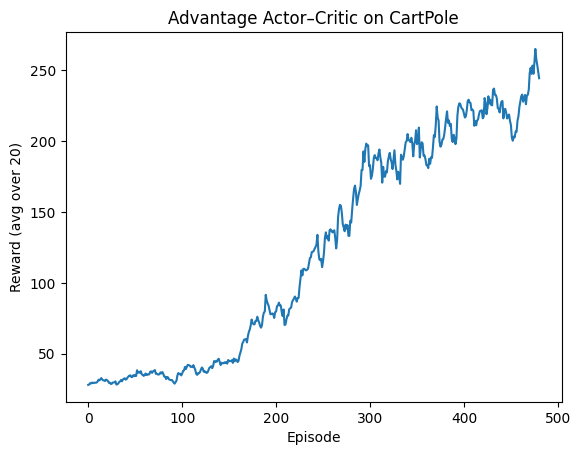

Final mean reward (last 50): 232.84
Episode   50 | Mean reward (last 50): 20.7
Episode  100 | Mean reward (last 50): 25.8
Episode  150 | Mean reward (last 50): 35.0
Episode  200 | Mean reward (last 50): 35.1
Episode  250 | Mean reward (last 50): 38.1
Episode  300 | Mean reward (last 50): 53.2
Episode  350 | Mean reward (last 50): 74.0
Episode  400 | Mean reward (last 50): 118.6
Episode  450 | Mean reward (last 50): 147.9
Episode  500 | Mean reward (last 50): 174.1


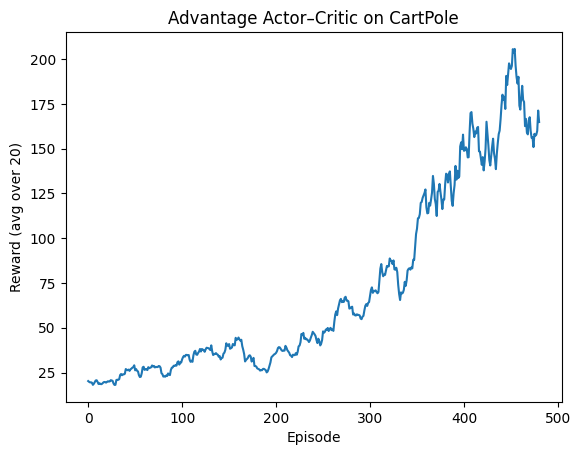

Final mean reward (last 50): 174.06
Episode   50 | Mean reward (last 50): 31.0
Episode  100 | Mean reward (last 50): 32.3
Episode  150 | Mean reward (last 50): 51.4
Episode  200 | Mean reward (last 50): 58.5
Episode  250 | Mean reward (last 50): 67.1
Episode  300 | Mean reward (last 50): 91.3
Episode  350 | Mean reward (last 50): 124.4
Episode  400 | Mean reward (last 50): 151.9
Episode  450 | Mean reward (last 50): 178.1
Episode  500 | Mean reward (last 50): 215.7


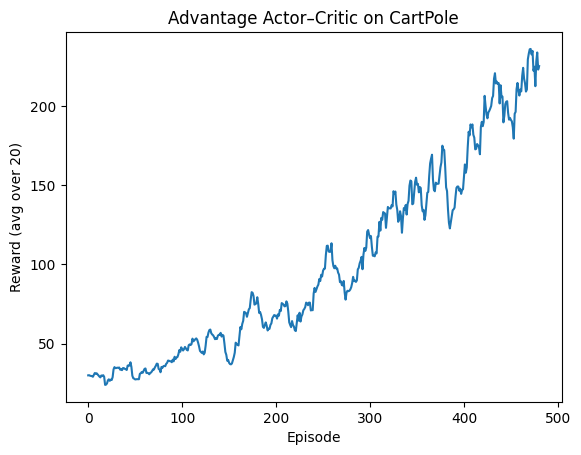

Final mean reward (last 50): 215.72


In [3]:
for critic_coef in [0.2, 0.5, 1.0]:

    model = ActorCritic()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    gamma = 0.99
    episodes = 500

    reward_hist = []

    for ep in range(episodes):
        logprobs, values, rewards = [], [], []
        s, info = env.reset()
        terminated = truncated = False
        ep_reward = 0.0

        while not (terminated or truncated):
            s_t = torch.tensor(s, dtype=torch.float32)
            probs, value = model(s_t)
            m = Categorical(probs)
            a = m.sample()
            s_next, r, terminated, truncated, info = env.step(a.item())

            logprobs.append(m.log_prob(a))
            values.append(value)
            rewards.append(r)
            ep_reward += r
            s = s_next

        # Compute returns and advantages
        returns = compute_returns(rewards, gamma)
        values = torch.cat(values).squeeze()
        advantage = returns - values.detach()

        # Losses
        actor_loss = -(torch.stack(logprobs) * advantage).mean()
        critic_loss = (returns - values).pow(2).mean()
        loss = actor_loss + critic_coef * critic_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        reward_hist.append(ep_reward)

        if (ep + 1) % 50 == 0:
            print(f"Episode {ep+1:4d} | Mean reward (last 50): {np.mean(reward_hist[-50:]):.1f}")

    # Plot learning curve
    window = 20
    ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
    plt.plot(ma)
    plt.title("Advantage Actor–Critic on CartPole")
    plt.xlabel("Episode")
    plt.ylabel(f"Reward (avg over {window})")
    plt.show()

    print("Final mean reward (last 50):", np.mean(reward_hist[-50:]))


3) Stretch (optional, 10–15 min)

Task: Add an entropy bonus to encourage exploration.
Hint: entropy = m.entropy().mean() and subtract β * entropy from total loss.

Episode   50 | Mean reward (last 50): 17.4
Episode  100 | Mean reward (last 50): 23.6
Episode  150 | Mean reward (last 50): 24.3
Episode  200 | Mean reward (last 50): 33.7
Episode  250 | Mean reward (last 50): 52.5
Episode  300 | Mean reward (last 50): 79.1
Episode  350 | Mean reward (last 50): 100.1
Episode  400 | Mean reward (last 50): 146.0
Episode  450 | Mean reward (last 50): 175.9
Episode  500 | Mean reward (last 50): 234.3


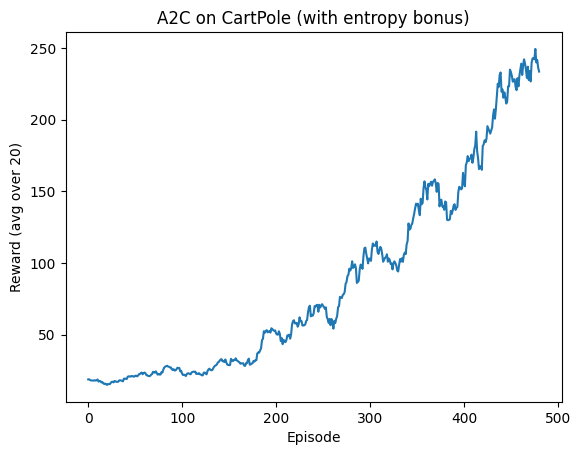

Final mean reward (last 50): 234.34


In [4]:
# Setup
import numpy as np, matplotlib.pyplot as plt
import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
np.random.seed(42); torch.manual_seed(42)

# Environment
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Actor–Critic network
class ActorCritic(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU())
        self.policy = nn.Sequential(nn.Linear(hidden, n_actions), nn.Softmax(dim=-1))
        self.value = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.shared(x)
        return self.policy(x), self.value(x)

model = ActorCritic()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
gamma = 0.99
episodes = 500
critic_coef = 0.5
beta = 1e-3   # entropy coefficient (tune: 5e-4–2e-3)

def compute_returns(rewards, gamma=0.99):
    G, ret = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        ret.append(G)
    ret.reverse()
    ret = torch.tensor(ret, dtype=torch.float32)
    if ret.std() > 0:
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    return ret

reward_hist = []

for ep in range(episodes):
    logprobs, values, rewards, ents = [], [], [], []
    s, info = env.reset()
    terminated = truncated = False
    ep_reward = 0.0

    while not (terminated or truncated):
        s_t = torch.tensor(s, dtype=torch.float32)
        probs, value = model(s_t)
        m = Categorical(probs)
        a = m.sample()

        s_next, r, terminated, truncated, info = env.step(a.item())

        logprobs.append(m.log_prob(a))
        ents.append(m.entropy())          # <-- collect entropy per step
        values.append(value)
        rewards.append(r)
        ep_reward += r
        s = s_next

    # Returns & advantages
    returns = compute_returns(rewards, gamma)
    values = torch.cat(values).squeeze()
    advantage = returns - values.detach()

    # Losses
    actor_loss = -(torch.stack(logprobs) * advantage).mean()
    critic_loss = (returns - values).pow(2).mean()
    entropy_loss = -beta * torch.stack(ents).mean()   # <-- entropy bonus (subtract)

    loss = actor_loss + critic_coef * critic_loss + entropy_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_hist.append(ep_reward)
    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1:4d} | Mean reward (last 50): {np.mean(reward_hist[-50:]):.1f}")

# Plot learning curve
window = 20
ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
plt.plot(ma)
plt.title("A2C on CartPole (with entropy bonus)")
plt.xlabel("Episode")
plt.ylabel(f"Reward (avg over {window})")
plt.show()

print("Final mean reward (last 50):", np.mean(reward_hist[-50:]))


Mini-Challenge (≤40 min) — “Fast Learner”

Goal: Train an A2C agent that reaches ≥200 average reward in fewer than 200 episodes.

Acceptance Criteria:

Uses advantage-based actor–critic loss.

Reaches target reward faster than REINFORCE.

Includes reward curve + short hyperparameter note.

Hint: Try smaller learning rate (5e-4), larger hidden (256), and entropy_bonus = 1e-3.

Episode   50 | Mean reward (last 50): 31.7
Episode  100 | Mean reward (last 50): 32.0
Episode  150 | Mean reward (last 50): 43.0
Episode  200 | Mean reward (last 50): 51.3
Episode  250 | Mean reward (last 50): 56.3
Episode  300 | Mean reward (last 50): 78.3
Episode  350 | Mean reward (last 50): 105.0
Episode  400 | Mean reward (last 50): 108.3
Episode  450 | Mean reward (last 50): 152.1
Episode  500 | Mean reward (last 50): 209.7


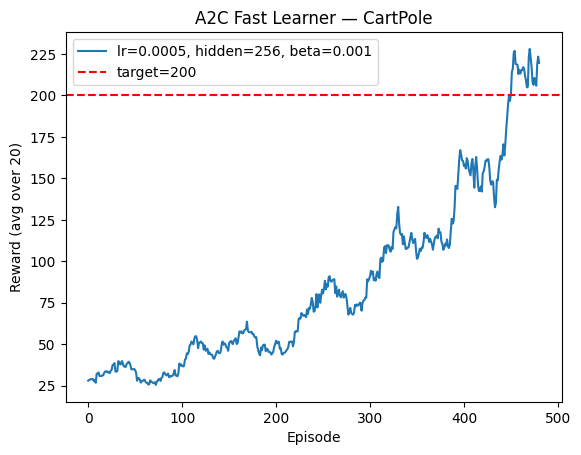

Final mean reward (last 50): 209.66


In [5]:
# === A2C Fast Learner (Mini-Challenge) ===
import numpy as np, matplotlib.pyplot as plt
import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
np.random.seed(42); torch.manual_seed(42)

# Environment
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Actor–Critic model
class ActorCritic(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU())
        self.policy = nn.Sequential(nn.Linear(hidden, n_actions), nn.Softmax(dim=-1))
        self.value = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.shared(x)
        return self.policy(x), self.value(x)

# Hyperparameters
lr = 5e-4
gamma = 0.99
beta = 1e-3         # entropy coefficient
critic_coef = 0.5
episodes = 500

model = ActorCritic()
optimizer = optim.Adam(model.parameters(), lr=lr)
reward_hist = []

def compute_returns(rewards, gamma=0.99):
    G, ret = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        ret.append(G)
    ret.reverse()
    ret = torch.tensor(ret, dtype=torch.float32)
    if ret.std() > 0:
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    return ret

for ep in range(episodes):
    logps, values, rewards, ents = [], [], [], []
    s, info = env.reset()
    terminated = truncated = False
    ep_reward = 0.0

    while not (terminated or truncated):
        s_t = torch.tensor(s, dtype=torch.float32)
        probs, value = model(s_t)
        m = Categorical(probs)
        a = m.sample()

        s_next, r, terminated, truncated, info = env.step(a.item())

        logps.append(m.log_prob(a))
        values.append(value)
        ents.append(m.entropy())
        rewards.append(r)
        ep_reward += r
        s = s_next

    # Compute advantage
    returns = compute_returns(rewards, gamma)
    values = torch.cat(values).squeeze()
    advantage = returns - values.detach()

    # Losses
    actor_loss = -(torch.stack(logps) * advantage).mean()
    critic_loss = (returns - values).pow(2).mean()
    entropy_loss = -beta * torch.stack(ents).mean()

    loss = actor_loss + critic_coef * critic_loss + entropy_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_hist.append(ep_reward)

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1:4d} | Mean reward (last 50): {np.mean(reward_hist[-50:]):.1f}")

# Plot moving-average reward
window = 20
ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
plt.plot(ma, label=f"lr={lr}, hidden=256, beta={beta}")
plt.axhline(200, color='r', ls='--', label='target=200')
plt.legend()
plt.title("A2C Fast Learner — CartPole")
plt.xlabel("Episode")
plt.ylabel(f"Reward (avg over {window})")
plt.show()

print("Final mean reward (last 50):", np.mean(reward_hist[-50:]))


Notes / Key Takeaways

Actor–Critic = direct policy + baseline for lower variance.

Critic stabilizes updates by estimating expected return.

Advantage At=Gt−V(st) tells the actor how surprising the outcome was.

Much smoother and sample-efficient than REINFORCE.

Forms foundation for A3C, PPO, and SAC algorithms.

Reflection

How did the critic change the learning dynamics vs. REINFORCE?

Why might too-strong a critic (large critic_coef) slow improvement?

How did the critic change the learning dynamics vs. REINFORCE?
The critic provided a baseline estimate of how good each state was, reducing the noise in the updates.
Instead of relying on the full episode return like REINFORCE (which has high variance), the actor in A2C learns from the advantage — the difference between what actually happened and what the critic expected.
This made learning more stable and faster, since gradients weren’t dominated by random lucky episodes.

Why might too-strong a critic (large critic_coef) slow improvement?
If the critic dominates the total loss, training focuses too much on predicting values accurately rather than improving the policy.
A “too-strong” critic can make the actor’s gradients weaker, reducing exploration and slowing behavioral improvement.
In short, the agent becomes a good estimator but not necessarily a better decision-maker — it learns to predict returns instead of maximizing them.